In [1]:
# 1. IMPORTS + CONFIG
import os, warnings, numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
RANDOM_STATE=19
TARGET="range_km"
NUMERIC_INPUTS=['battery_capacity_kWh', 'torque_nm', 'top_speed_kmh', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm', 'width_mm', 'height_mm']
FORBIDDEN=["brand","model","battery_type","fast_charge_port","source_url","efficiency_wh_per_km","number_of_cells","drivetrain","segment","car_body_type"]
DATA_FILE="EV_Range_Expanded_Verified_Training_FINAL.csv"
if not os.path.exists(DATA_FILE): DATA_FILE="/mnt/data/EV_Range_Expanded_Verified_Training_FINAL.csv"
print("Ready. Data file:",DATA_FILE)


Ready. Data file: /mnt/data/EV_Range_Expanded_Verified_Training_FINAL.csv


In [2]:
# 2. LOAD + CLEAN
ev=pd.read_csv(DATA_FILE)
required=NUMERIC_INPUTS+[TARGET]
missing=[c for c in required if c not in ev.columns]
if missing: raise ValueError("Missing required columns: "+", ".join(missing))
df=ev.copy()
for c in required: df[c]=pd.to_numeric(df[c].astype(str).str.replace(",","",regex=False),errors="coerce")
df=df.dropna(subset=[TARGET]).drop_duplicates().reset_index(drop=True)
print("Rows:",len(df),"| Range:",float(df[TARGET].min()),"to",float(df[TARGET].max()),"km")


Rows: 496 | Range: 135.0 to 685.0 km


In [3]:
# 3. LEAKAGE-SAFE FEATURE ENGINEERING
def build_features(frame):
    x=frame[NUMERIC_INPUTS].copy()
    for c in NUMERIC_INPUTS: x[c]=pd.to_numeric(x[c],errors="coerce")
    x["vehicle_volume_m3"]=x["length_mm"]*x["width_mm"]*x["height_mm"]/1e9
    x["vehicle_footprint_m2"]=x["length_mm"]*x["width_mm"]/1e6
    x["battery_per_volume"]=x["battery_capacity_kWh"]/x["vehicle_volume_m3"].replace(0,np.nan)
    x["battery_per_seat"]=x["battery_capacity_kWh"]/x["seats"].replace(0,np.nan)
    return x.replace([np.inf,-np.inf],np.nan)
X=build_features(df); y=df[TARGET].astype(float)
assert not (set(FORBIDDEN)&set(X.columns))
assert "efficiency_wh_per_km" not in X.columns
print("Features:",X.columns.tolist())


Features: ['battery_capacity_kWh', 'torque_nm', 'top_speed_kmh', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm', 'width_mm', 'height_mm', 'vehicle_volume_m3', 'vehicle_footprint_m2', 'battery_per_volume', 'battery_per_seat']


In [4]:
# 4. FIXED HOLD-OUT SPLIT
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=RANDOM_STATE)
print("Train:",len(X_train),"| Test:",len(X_test))


Train: 396 | Test: 100


In [5]:
# 5. CATBOOST VALIDATION + EARLY STOPPING
BASE_PARAMS=dict(iterations=1800,depth=5,learning_rate=0.02,l2_leaf_reg=8,loss_function="MAE",random_strength=1.0,random_seed=RANDOM_STATE,verbose=False,allow_writing_files=False,thread_count=2)
kf=KFold(n_splits=3,shuffle=True,random_state=RANDOM_STATE)
fold_mae=[]; best_iters=[]
for fold,(tr,va) in enumerate(kf.split(X_train),1):
    model=CatBoostRegressor(**BASE_PARAMS)
    model.fit(X_train.iloc[tr],y_train.iloc[tr],eval_set=(X_train.iloc[va],y_train.iloc[va]),early_stopping_rounds=120)
    p=model.predict(X_train.iloc[va])
    fold_mae.append(mean_absolute_error(y_train.iloc[va],p)); best_iters.append(model.get_best_iteration())
    print(f"Fold {fold}: MAE={fold_mae[-1]:.2f} km | best_iteration={best_iters[-1]}")
FINAL_ITERATIONS=max(100,int(round(np.mean(best_iters))))
print(f"CV MAE: {np.mean(fold_mae):.2f} +/- {np.std(fold_mae):.2f} km")
print("Final iterations:",FINAL_ITERATIONS)


Fold 1: MAE=15.31 km | best_iteration=1799


Fold 2: MAE=13.37 km | best_iteration=1781


Fold 3: MAE=14.81 km | best_iteration=1799
CV MAE: 14.50 +/- 0.82 km
Final iterations: 1793


In [6]:
# 6. UNTOUCHED HOLD-OUT EVALUATION
EVAL_PARAMS=BASE_PARAMS.copy(); EVAL_PARAMS["iterations"]=FINAL_ITERATIONS
test_model=CatBoostRegressor(**EVAL_PARAMS); test_model.fit(X_train,y_train)
pred=test_model.predict(X_test)
mae=mean_absolute_error(y_test,pred); rmse=np.sqrt(mean_squared_error(y_test,pred)); r2=r2_score(y_test,pred)
print(f"MAE : {mae:.2f} km\nRMSE: {rmse:.2f} km\nR²  : {r2:.4f}")
actual_vs_predicted=pd.DataFrame({"Actual range (km)":y_test.to_numpy(),"Predicted range (km)":np.round(pred,2)})
actual_vs_predicted["Absolute error (km)"]=np.round(np.abs(actual_vs_predicted.iloc[:,0]-actual_vs_predicted.iloc[:,1]),2)
actual_vs_predicted["Signed error (km)"]=np.round(actual_vs_predicted.iloc[:,1]-actual_vs_predicted.iloc[:,0],2)
actual_vs_predicted=actual_vs_predicted.sort_values("Actual range (km)").reset_index(drop=True)
actual_vs_predicted.to_csv("EV_Range_Actual_vs_Predicted_FINAL_WEBSITE_READY.csv",index=False)
display(actual_vs_predicted)


MAE : 10.48 km
RMSE: 16.59 km
R²  : 0.9697


,Actual range (km),Predicted range (km),Absolute error (km),Signed error (km)
0,135.0,135.00,0.00,0.00
1,165.0,160.33,4.67,-4.67
2,215.0,214.30,0.70,-0.70
3,230.0,230.86,0.86,0.86
4,230.0,244.82,14.82,14.82
...,...,...,...,...
95,535.0,527.99,7.01,-7.01
96,540.0,536.93,3.07,-3.07
97,560.0,563.89,3.89,3.89
98,570.0,546.74,23.26,-23.26


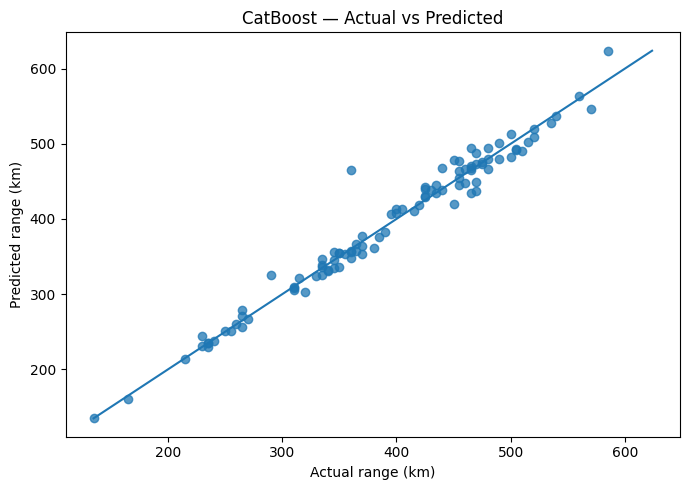

Worst absolute error: 104.64 km


In [7]:
# 7. ACTUAL vs PREDICTED + ERROR SUMMARY
plt.figure(figsize=(7,5)); plt.scatter(y_test,pred,alpha=0.75)
lo=min(float(y_test.min()),float(pred.min())); hi=max(float(y_test.max()),float(pred.max())); plt.plot([lo,hi],[lo,hi])
plt.xlabel("Actual range (km)"); plt.ylabel("Predicted range (km)"); plt.title("CatBoost — Actual vs Predicted"); plt.tight_layout(); plt.show()
print("Worst absolute error:",float(actual_vs_predicted["Absolute error (km)"].max()),"km")


In [8]:
# 8. FINAL MODEL ON ALL DATA + SAVE
FINAL_PARAMS=BASE_PARAMS.copy(); FINAL_PARAMS["iterations"]=FINAL_ITERATIONS
final_model=CatBoostRegressor(**FINAL_PARAMS); final_model.fit(X,y)
MODEL_PATH="ev_range_catboost_final_website_ready.joblib"
artifact={"model":final_model,"feature_columns":X.columns.tolist(),"numeric_inputs":NUMERIC_INPUTS,"target":TARGET,"model_name":"CatBoostRegressor","best_params":FINAL_PARAMS,"random_state":RANDOM_STATE,"feature_engineering":"vehicle volume, vehicle footprint, battery per volume, battery per seat","forbidden_inputs":FORBIDDEN}
joblib.dump(artifact,MODEL_PATH); print("Saved:",MODEL_PATH)


Saved: ev_range_catboost_final_website_ready.joblib


In [9]:
# 9. WEBSITE/API PREDICTOR
def predict_new_ev(**values):
    missing=[c for c in NUMERIC_INPUTS if c not in values]
    if missing: raise ValueError("Missing inputs: "+", ".join(missing))
    raw=pd.DataFrame([{c:values[c] for c in NUMERIC_INPUTS}])
    for c in NUMERIC_INPUTS: raw[c]=pd.to_numeric(raw[c],errors="coerce")
    bad=[c for c in NUMERIC_INPUTS if pd.isna(raw.loc[0,c])]
    if bad: raise ValueError("Invalid numeric inputs: "+", ".join(bad))
    features=build_features(raw).reindex(columns=X.columns)
    return max(0.0,round(float(final_model.predict(features)[0]),2))

TEST_INPUT={"battery_capacity_kWh":75,"torque_nm":450,"top_speed_kmh":200,"acceleration_0_100_s":4.5,"fast_charging_power_kw_dc":150,"towing_capacity_kg":1000,"cargo_volume_l":450,"seats":5,"length_mm":4700,"width_mm":1850,"height_mm":1600}
print("Website smoke test prediction:",predict_new_ev(**TEST_INPUT),"km")


Website smoke test prediction: 429.24 km


In [10]:
# 10. SIMPLE NUMERIC LIVE INTERFACE
try:
    import ipywidgets as widgets
    from IPython.display import display,clear_output
    defaults={"battery_capacity_kWh":75.0,"torque_nm":450.0,"top_speed_kmh":200.0,"acceleration_0_100_s":4.5,"fast_charging_power_kw_dc":150.0,"towing_capacity_kg":1000.0,"cargo_volume_l":450.0,"seats":5.0,"length_mm":4700.0,"width_mm":1850.0,"height_mm":1600.0}
    controls={c:widgets.FloatText(value=defaults[c],description=c.replace("_"," "),style={"description_width":"180px"},layout=widgets.Layout(width="520px")) for c in NUMERIC_INPUTS}
    button=widgets.Button(description="PREDICT RANGE",button_style="success",layout=widgets.Layout(width="250px",height="45px")); output=widgets.Output()
    def clicked(_):
        with output:
            clear_output()
            try:
                vals={c:w.value for c,w in controls.items()}; print("="*48); print(f"Predicted range: {predict_new_ev(**vals):.2f} km"); print("Model: CatBoost"); print("="*48)
            except Exception as e: print("Prediction error:",e)
    button.on_click(clicked); display(widgets.VBox([widgets.HTML("<h2>⚡ EV Range Predictor</h2>"),*controls.values(),button,output]))
except ImportError: print("ipywidgets not installed; use predict_new_ev() or the website module.")


ipywidgets not installed; use predict_new_ev() or the website module.


In [11]:
# 11. FINAL CHECKS
assert TARGET in df.columns
assert not (set(FORBIDDEN)&set(X.columns))
assert "efficiency_wh_per_km" not in X.columns
assert all(c in X.columns for c in NUMERIC_INPUTS)
assert np.isfinite(pred).all()
assert len(actual_vs_predicted)==len(y_test)
assert os.path.exists(MODEL_PATH)
assert predict_new_ev(**TEST_INPUT)>0
print("ALL FINAL SYSTEM CHECKS PASSED")
print(f"Hold-out MAE={mae:.2f} km | RMSE={rmse:.2f} km | R²={r2:.4f}")


ALL FINAL SYSTEM CHECKS PASSED
Hold-out MAE=10.48 km | RMSE=16.59 km | R²=0.9697
